In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
import nbformat

In [2]:
load_dotenv()

groq_llm = ChatGroq(
    model_name = "llama-3.3-70b-versatile",
    temperature=0.5
)

llama_llm = ChatOllama(
    base_url="http://localhost:11434",
    model = "llama3.2",
    temperature=0.6
)

In [3]:
class TweetevaluationSchema(BaseModel):
    evaluation: Literal["Approved", "Needs Improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(...,description="feedback for the post.")

In [4]:
eval_llm = groq_llm.with_structured_output(TweetevaluationSchema)

In [5]:
# State
class PGState(TypedDict):
    topic: str
    file: str
    post: str
    context: str 
    evaluation: Literal["Approved", "Needs Improvement"]
    feedback: str
    iteration: int
    max_iteration: int


In [6]:
graph = StateGraph(PGState)

In [ ]:
def parse_notebook(file_path):    
    # read and Get data out of the file
    def read_file(file_path):
        with open(file_path, "r", encoding = "utf-8") as f:
            nb = nbformat.read(f, as_version=4)
        notebook_content = []
        for i, cell in enumerate(nb.cells):
            cell_data = {
                "cell_index" : i,
                "type" : cell.cell_type,
                "content" : "".join(cell.source).strip() 
            }
            if cell.cell_type == "code":
                outputs = []
                for output in cell.get("outputs", []):
                    # Case 1: print statements / stdout
                    if output.output_type == "stream":
                        outputs.append(output.get("text", ""))
                    # Case 2: execution result (e.g., dataframe head)
                    elif output.output_type == "execute_result":
                        data = output.get("data", {})
                        if "text/plain" in data:
                            outputs.append(data["text/plain"])
                    # Case 3: display data (similar to execute result)
                    elif output.output_type == "display_data":
                        data = output.get("data", {})
                        if "text/plain" in data:
                            outputs.append(data["text/plain"])
                    # Case 4: errors 
                    elif output.output_type == "error":
                        outputs.append("\n".join(output.get("traceback", [])))
                cell_data["outputs"] =  "\n".join(outputs).strip()
            notebook_content.append(cell_data)
        return notebook_content
    
    # Label data
    def notebook_to_text(file_path):
        notebook_content = read_file(file_path)
        text_output = []
        for cell in notebook_content:
            if cell['type'] == "markdown":
                text_output.append(f"[markdown]\n{cell['content']}\n")
            elif cell['type'] == "code":
                text_output.append(f"[code]\n{cell['content']}\n")
                if cell.get("outputs"):
                    text_output.append(f"[output]\n{cell['outputs']}\n")
        return "\n".join(text_output)
    
    notebook_context = notebook_to_text(file_path)
    return notebook_context




In [8]:
def get_context(state: PGState):
    path = state['file']
    notebook_context = parse_notebook(path)
    prompt = f"""
        You are an expert data analyst.

        Below is a Jupyter notebook content with markdown, code, and outputs.

        Your job is to deeply understand what is happening.

        Step 1: Explain the notebook step-by-step in simple terms.
        Step 2: Identify the goal of the notebook.
        Step 3: Extract the workflow (sequence of steps).
        Step 4: Identify key results from outputs.
        Step 5: Highlight important insights.

        Notebook:
        {notebook_context}

        Return output in this structured format:

        GOAL:
        ...

        WORKFLOW:
        - step 1
        - step 2

        KEY STEPS:
        ...

        RESULTS:
        ...

        INSIGHTS:
        ...
    """

    context = llama_llm.invoke(prompt).content
    return {"context" : context}

In [9]:
def MakePost(state: PGState):

    messages = [
        SystemMessage(content="You are a clear, thoughtful LinkedIn creator who shares learning journeys   and projects in a professional, grounded, and easy-to-understand way."),
        
        HumanMessage(content=f"""
        Write a LinkedIn post about my learning journey or a project I recently built on the topic: "{state['topic']}".

        Context you can use (if provided):
        {state.get('context', '')}

        Rules:
        - Keep the tone professional, simple, and reflective
        - Focus on what I learned, built, or explored
        - Explain the project or concept clearly in plain English
        - Highlight key features or takeaways (use bullet points if useful)
        - Avoid hype, exaggeration, or buzzwords
        - Use short paragraphs for readability
        - Do not overuse emojis (prefer none)
        - End with a brief forward-looking or reflective closing
        - Add 3-5 relevant hashtags

        Strict Output Rules:
        - Output ONLY the final post content
        - Do NOT add any introduction like "Here is your post"
        - Do NOT add any explanation before or after the post
        - Do NOT mention AI, generation, or writing process
        - Do NOT use quotes around the post

        Structure:
        1. What I started learning or building
        2. What I built or explored
        3. Key takeaways or features
        4. Reflection or next steps
        5. Hashtags
        """)
    ]

    post = llama_llm.invoke(messages).content

    return {'post': post}



In [10]:
def EvaluatePost(state: PGState):
    # Prompt
    messages = [
        SystemMessage(content="You are a sharp, no-nonsense LinkedIn content critic. You evaluate posts based on clarity, authenticity, structure, and professional value."),
        
        HumanMessage(content=f"""
            Evaluate the following LinkedIn post:

            Post: "{state['post']}"

            Use the criteria below to evaluate the post:

            1. Clarity - Is the idea explained clearly and easy to follow?
            2. Authenticity - Does it feel genuine and grounded, or generic and performative?
            3. Value - Does it provide meaningful insights, learnings, or takeaways?
            4. Structure - Is it well-organized with good flow and readable formatting?
            5. Engagement Potential - Would this make someone pause, read, or engage?

            Auto-reject if:
            - It is overly generic or reads like a template with no real insight
            - It uses excessive buzzwords or hype language
            - It lacks a clear learning, takeaway, or outcome
            - It is poorly structured or hard to read (long blocks, no flow)
            - It feels self-promotional without substance

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs improvement"
            - feedback: One paragraph explaining the strengths and weaknesses
        """)
    ]

    # llm result
    result = eval_llm.invoke(messages)
    # save it
    return {'evaluation': result.evaluation, 'feedback': result.feedback}




In [ ]:
def OptimizePost(state: PGState):
    messages = [
        SystemMessage(content="You refine LinkedIn posts to improve clarity, authenticity, structure, and professional value based on feedback."),
        
        HumanMessage(content=f"""
            Improve the LinkedIn post based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"

            Original Post:
            {state['post']}

            Rewrite it as a clear, well-structured LinkedIn post.

            Rules:
            - Keep the tone professional, simple, and reflective
            - Improve clarity and flow
            - Make the learning or project more concrete and specific
            - Strengthen key takeaways or insights
            - Avoid buzzwords, hype, or generic statements
            - Use short paragraphs and bullet points if helpful
            - Keep it concise but complete
            - Do not overuse emojis (prefer none)
            - End with a thoughtful closing line
            - Add 3-5 relevant hashtags

            Strict Output Rules:
            - Output ONLY the final post content
            - Do NOT add any introduction like "Here is your post"
            - Do NOT add any explanation before or after the post
            - Do NOT mention AI, generation, or writing process
            - Do NOT use quotes around the post
        """)
    ]

    result = groq_llm.invoke(messages).content
    
    return {'post': result, "iteration": state['iteration']+1}



In [12]:
def check_context(state: PGState):
    path = state.get("file")
    return "context" if isinstance(path, str) and path.strip() else "post"

In [13]:
def check_post(state: PGState):
    if state['evaluation'].lower() == 'approved' or state['iteration'] >= state['max_iteration']:
        return "Approved"
    elif state['evaluation'].lower() == "needs improvement":
        return "Optimize"
    

In [14]:
graph.add_node("Get_Context", get_context)
graph.add_node("Make_Post", MakePost)
graph.add_node("Evaluate_Post", EvaluatePost)
graph.add_node("Optimize_Post", OptimizePost)

In [15]:
graph.add_conditional_edges(START, check_context, {"context": "Get_Context", "post":"Make_Post"})
graph.add_edge("Get_Context", "Make_Post")
graph.add_edge("Make_Post","Evaluate_Post")
graph.add_conditional_edges("Evaluate_Post",check_post, {"Approved":END, "Optimize":"Optimize_Post"})
graph.add_edge("Optimize_Post","Evaluate_Post")

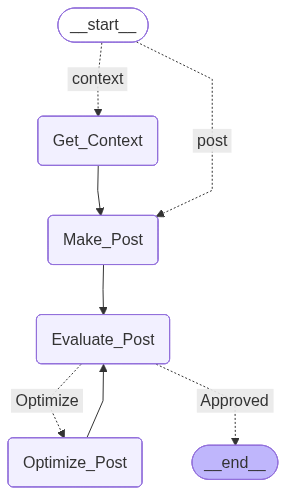

In [16]:
workflow = graph.compile()
workflow

In [17]:
initial_state = {
    "topic":"AI", 
    "iteration" : 1,
    "max_iteration": 5
    }
final_state = workflow.invoke(initial_state)

In [18]:
print(final_state['post'])
print("-"*50)
print(final_state['feedback'])
print("-"*50)
print(final_state['evaluation'])
print("-"*50)
print(final_state['iteration'])

I recently delved into the world of machine learning and created a simple chatbot using Python and its popular library, NLTK. This project allowed me to explore the basics of natural language processing and how it can be applied in real-world applications.

I started by learning about the fundamentals of machine learning, including supervised and unsupervised learning methods. I also learned about data preprocessing techniques such as tokenization and stemming.

What I built was a basic chatbot that could understand simple user queries and respond accordingly. The chatbot used a dictionary-based approach to map keywords to predefined responses.

Key features of the project include:
* Ability to understand simple sentences
* Response generation based on keyword matching
* Basic error handling for unknown inputs

Through this project, I gained valuable insights into the importance of data quality and preprocessing in machine learning. I also learned about the limitations of dictionary-ba

In [19]:
initial_state1 = {
    "topic":"First program using LangGraph", 
    "file":r"C:\Users\bathr\Desktop\Cybrom_Class_Data\SELF GenAI Projects\Tutorial_files\LangGraph\workflows\Conditional_workflows\Quadratic_Equation_Solver.ipynb",
    "iteration" : 1,
    "max_iteration": 5
    }
final_state1 = workflow.invoke(initial_state1)

In [20]:
print(final_state1['post'])
print("-"*50)
print(final_state1['feedback'])
print("-"*50)
print(final_state1['evaluation'])
print("-"*50)
print(final_state1['iteration'])

Building with LangGraph: Determining Quadratic Equation Roots

I recently embarked on a journey to learn about LangGraph, a Python library for building and executing graph-based workflows. My goal was to determine the nature of the roots of a quadratic equation, specifically whether they are real or complex, and if they are repeated or distinct.

To achieve this, I created a `StateGraph` object, which represents the states and transitions between them. The graph is populated with nodes for each function that will be executed: `show_equation`, `calculate_determinant`, `real_roots`, `no_real_roots`, and `repeated_roots`. 

Here are some key features of my project:

*   **Conditional Edges**: I used conditional edges in the graph to implement complex logic and decision-making processes.
*   **Compilation and Invocation**: The graph is compiled into a executable workflow using the `compile()` method, and invoked with an initial state containing the coefficients `a`, `b`, and `c` of the qua

In [21]:
print(final_state1['context'])

**GOAL:**
The goal of this notebook is to determine the nature of the roots of a quadratic equation, specifically whether they are real or complex, and if they are repeated or distinct.

**WORKFLOW:**

1. **Step 1:** The workflow starts with creating a `StateGraph` object, which represents the states and transitions between them.
2. **Step 2:** The graph is populated with nodes for each function that will be executed:
	* `show_equation`: displays the equation in a human-readable format based on the coefficients `a`, `b`, and `c`.
	* `calculate_determinant`: calculates the discriminant of the quadratic equation.
	* `real_roots`, `no_real_roots`, and `repeated_roots`: determine the nature of the roots based on the determinant value.

**KEY STEPS:**

* The graph is compiled into a executable workflow using the `compile()` method.
* The workflow is invoked with an initial state, which contains the coefficients `a`, `b`, and `c` of the quadratic equation.
* The output of each function is st